# Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Dataset Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!find /content/drive/MyDrive -name "*archive-3*"

/content/drive/MyDrive/archive-3 (1).zip
/content/drive/MyDrive/Copy of archive-3 (1).zip
/content/drive/MyDrive/Copy of archive-3.zip
/content/drive/MyDrive/archive-3.zip


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/archive-3 (1).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Done


In [5]:
import os

for root, dirs, files in os.walk("/content"):
    print(root)

/content
/content/.config
/content/.config/logs
/content/.config/logs/2026.06.04
/content/.config/configurations
/content/dataset
/content/dataset/archive-3
/content/dataset/archive-3/train
/content/dataset/archive-3/train/happy
/content/dataset/archive-3/train/angry
/content/dataset/archive-3/train/fear
/content/dataset/archive-3/train/surprise
/content/dataset/archive-3/train/neutral
/content/dataset/archive-3/train/sad
/content/dataset/archive-3/train/disgust
/content/dataset/archive-3/test
/content/dataset/archive-3/test/happy
/content/dataset/archive-3/test/angry
/content/dataset/archive-3/test/fear
/content/dataset/archive-3/test/surprise
/content/dataset/archive-3/test/neutral
/content/dataset/archive-3/test/sad
/content/dataset/archive-3/test/disgust
/content/dataset/__MACOSX
/content/dataset/__MACOSX/archive-3
/content/dataset/__MACOSX/archive-3/train
/content/dataset/__MACOSX/archive-3/train/happy
/content/dataset/__MACOSX/archive-3/train/angry
/content/dataset/__MACOSX/archi

In [6]:
train_path = "/content/dataset/archive-3/train"
test_path = "/content/dataset/archive-3/test"

# Data Generator

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 48
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [8]:
print(train_data.class_indices)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


# CNN Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 4
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Fully Connected
model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 524,935 (2.00 MB)

 Trainable params: 523,975 (2.00 MB)

 Non-trainable params: 960 (3.75 KB)

# Compile Model

In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_emotion_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

# Train Model

In [12]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 48s 79ms/step - accuracy: 0.2065 - loss: 2.1978 - val_accuracy: 0.2424 - val_loss: 1.9350
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.2398 - loss: 1.8623 - val_accuracy: 0.2956 - val_loss: 1.7363
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.2573 - loss: 1.7971 - val_accuracy: 0.3186 - val_loss: 1.7129
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.2835 - loss: 1.7562 - val_accuracy: 0.3420 - val_loss: 1.6978
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.3047 - loss: 1.7213 - val_accuracy: 0.3438 - val_loss: 1.7723
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.3240 - loss: 1.6901 - val_accuracy: 0.3668 - val_loss: 1.6931
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.3361 - loss: 1.6637 - val_accuracy: 0.3639 - val_loss: 1.7119
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.3511 - loss: 1.6427 - 

# Accuracy & Loss Graph

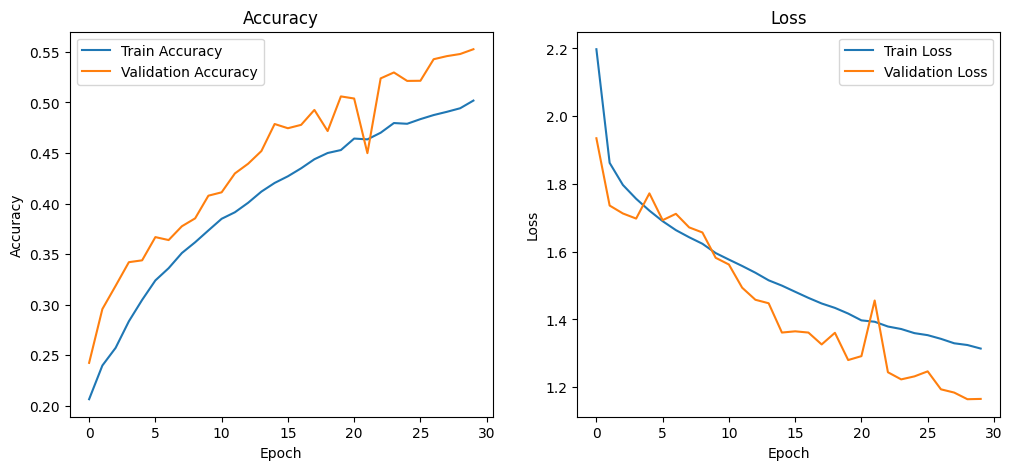

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.show()

# Evaluate Model

In [14]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5479 - loss: 1.1645
Test Loss : 1.164506435394287
Test Accuracy : 0.5479242205619812


# Save Final Model

In [15]:
model.save("emotion_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


# Download Model

In [23]:
from google.colab import files

files.download("emotion_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Upload Test Image

In [24]:
from google.colab import files

uploaded = files.upload()

Saving ._PrivateTest_88305.jpg to ._PrivateTest_88305.jpg


In [20]:
import os

print(os.listdir())

['.config', 'dataset', 'drive', 'best_emotion_model.keras', 'emotion_model.keras', '._Training_3908.jpg', 'sample_data']
